# NO4LSP Assignment 2.1 — Derivative-based Optimization

**Metodo:** Steepest Descent + Armijo Backtracking  
**Funzioni test:**
- Problem 16: Banded Trigonometric (Hessiana banded)
- Problem 28: Variably Dimensioned (Hessiana piena — rank-1 update di $I$)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

---
## Problem 16 — Banded Trigonometric

$$F(x) = \sum_{i=1}^{n} i \cdot \left[(1 - \cos x_i) + \sin x_{i-1} - \sin x_{i+1}\right]$$

con $x_0 = x_{n+1} = 0$ (bordi fissi), punto iniziale $\bar{x}_i = 1$, $i \geq 1$.

**Gradiente esatto:**
- Interno ($1 < j < n$): $\;\partial F/\partial x_j = j \sin(x_j) + 2\cos(x_j)$
- Bordo $j=1$: $\;\sin(x_1) + 2\cos(x_1)$
- Bordo $j=n$: $\;n\sin(x_n) - (n-1)\cos(x_n)$

In [16]:
# Funzione e gradiente esatto importati da src/ (vedi src/functions/problem16.py
# e src/gradients/problem16.py).
from src.functions.problem16 import f16, x_bar_16
from src.gradients.problem16 import grad_f16

### Test rapido per n=2

Per $n=2$, la funzione diventa esplicitamente:

$$F(x_1, x_2) = (1 - \cos x_1) - \sin x_2 + 2(1 - \cos x_2) + 2\sin x_1$$

Verifica che `f16(np.array([1.0, 1.0]))` restituisca un numero ragionevole prima di plottare.

In [17]:
# Verifica per n=2
x_test = np.array([1.0, 1.0])
print("F(1,1) =", f16(x_test))
print("grad F(1,1) =", grad_f16(x_test))

F(1,1) = 2.220564067203477
grad F(1,1) = [1.9220756  1.14263966]


### Visualizzazione del paesaggio per n=2

Crea una griglia $(x_1, x_2)$ in un range ragionevole (es. $[-3, 3] \times [-3, 3]$),
calcola $F$ su ogni punto, e plotta con `plt.contourf` + `plt.colorbar`.

Aggiungi poi il punto di partenza $\bar{x} = (1, 1)$ come punto rosso.

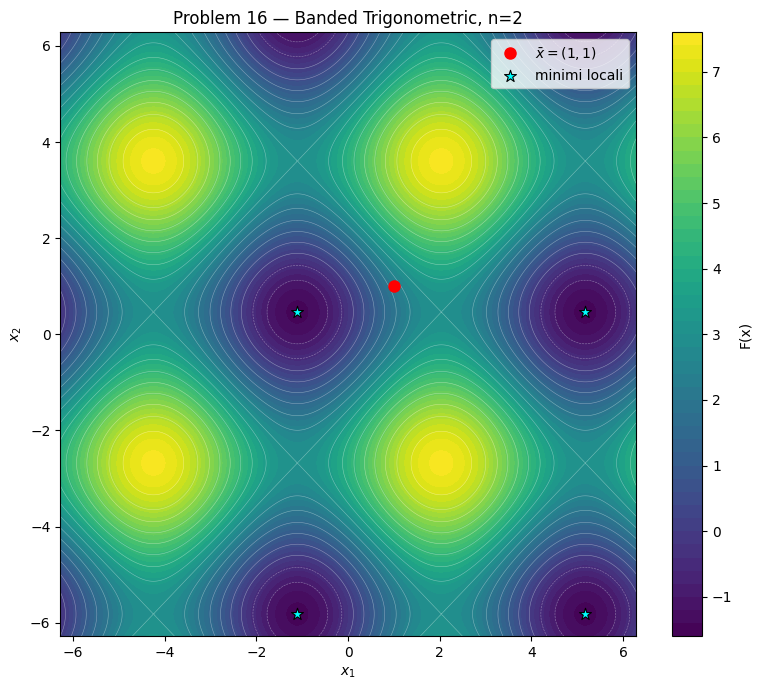

In [18]:
# Visualizzazione Problem 16, n=2 (range esteso per vedere piu minimi locali)
x_lo, x_hi = -2*np.pi, 2*np.pi
x1_range = np.linspace(x_lo, x_hi, 400)
x2_range = np.linspace(x_lo, x_hi, 400)
X1, X2 = np.meshgrid(x1_range, x2_range)

Z = np.vectorize(lambda a, b: f16(np.array([a, b])))(X1, X2)

# Minimi locali analitici (problema separabile per n=2):
#   d/dx1 = sin x1 + 2 cos x1 = 0  =>  tan x1 = -2,  con  cos x1 > 0  (k pari)
#   d/dx2 = 2 sin x2 - cos x2 = 0  =>  tan x2 = 1/2, con  2 cos x2 + sin x2 > 0  (k pari)
x1_min_base = np.arctan2(-2.0, 1.0)   # ≈ -1.107  (ramo con cos > 0)
x2_min_base = np.arctan2( 1.0, 2.0)   # ≈  0.464  (ramo con cos > 0)
ks = np.arange(-3, 4)
x1_mins = x1_min_base + 2*np.pi*ks
x2_mins = x2_min_base + 2*np.pi*ks
x1_mins = x1_mins[(x1_mins >= x_lo) & (x1_mins <= x_hi)]
x2_mins = x2_mins[(x2_mins >= x_lo) & (x2_mins <= x_hi)]
X1m, X2m = np.meshgrid(x1_mins, x2_mins)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(X1, X2, Z, levels=50, cmap='viridis')
ax.contour(X1, X2, Z, levels=20, colors='white', linewidths=0.4, alpha=0.4)
ax.plot(1, 1, 'ro', markersize=8, label=r'$\bar{x} = (1,1)$')
ax.scatter(X1m.ravel(), X2m.ravel(), c='cyan', s=80, marker='*',
           edgecolor='black', linewidths=0.8, label='minimi locali', zorder=5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Problem 16 — Banded Trigonometric, n=2')
plt.colorbar(cf, ax=ax, label='F(x)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

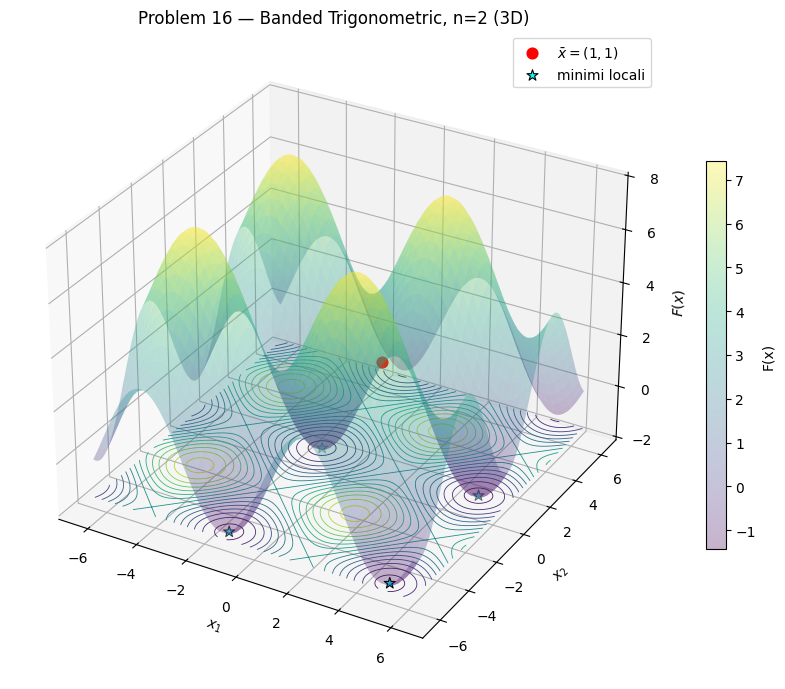

In [19]:
# Visualizzazione 3D Problem 16, n=2
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registra il proiettore 3d)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X1, X2, Z, cmap='viridis',
                       linewidth=0, antialiased=True, alpha=0.3)
# isolinee proiettate sul piano di base
ax.contour(X1, X2, Z, zdir='z', offset=Z.min(), levels=15,
           cmap='viridis', linewidths=0.6)

# punto iniziale
ax.scatter([1], [1], [f16(np.array([1.0, 1.0]))],
           color='red', s=60, label=r'$\bar{x}=(1,1)$')

# minimi locali (riusa X1m, X2m calcolati nella cella 2D)
mins_xy = np.column_stack([X1m.ravel(), X2m.ravel()])
mins_z = np.array([f16(np.array(p)) for p in mins_xy])
ax.scatter(mins_xy[:, 0], mins_xy[:, 1], mins_z,
           c='cyan', s=70, marker='*', edgecolor='black',
           linewidths=0.8, label='minimi locali')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$F(x)$')
ax.set_title('Problem 16 — Banded Trigonometric, n=2 (3D)')
fig.colorbar(surf, ax=ax, shrink=0.6, label='F(x)')
ax.view_init(elev=30, azim=-60)
ax.legend()
plt.tight_layout()
plt.show()

---
## Problem 28 — Variably Dimensioned

$$F(x) = \frac{1}{2}\sum_{k=1}^{n+2} f_k(x)^2$$

con $f_k(x) = x_k - 1$ per $1 \le k \le n$, $f_{n+1}(x) = \sum_{i=1}^n i(x_i - 1) \equiv S(x)$, $f_{n+2}(x) = S(x)^2$, e punto iniziale $\bar{x}_l = 1 - l/n$.

Forma compatta (posto $S := \sum_i i(x_i - 1)$):
$$F(x) = \tfrac{1}{2}\left[\sum_{k=1}^n (x_k - 1)^2 + S^2 + S^4\right]$$

**Gradiente esatto:**
$$\partial F/\partial x_j = (x_j - 1) + j \cdot S \cdot (1 + 2 S^2)$$

**Hessiana piena** (rank-1 update di $I$):
$$H = I + (1 + 6 S^2)\,\mathbf{j}\,\mathbf{j}^\top, \qquad \mathbf{j} = (1, 2, \ldots, n)^\top$$

$F$ è convessa (somma di norme quadratiche e di $S^2,\,S^4$ con $S$ lineare): unico minimo globale a $x^* = (1, \ldots, 1)$ con $F^* = 0$.

In [20]:
# Funzione e gradiente esatto importati da src/ (vedi src/functions/problem28.py
# e src/gradients/problem28.py).
from src.functions.problem28 import f28, x_bar_28
from src.gradients.problem28 import grad_f28

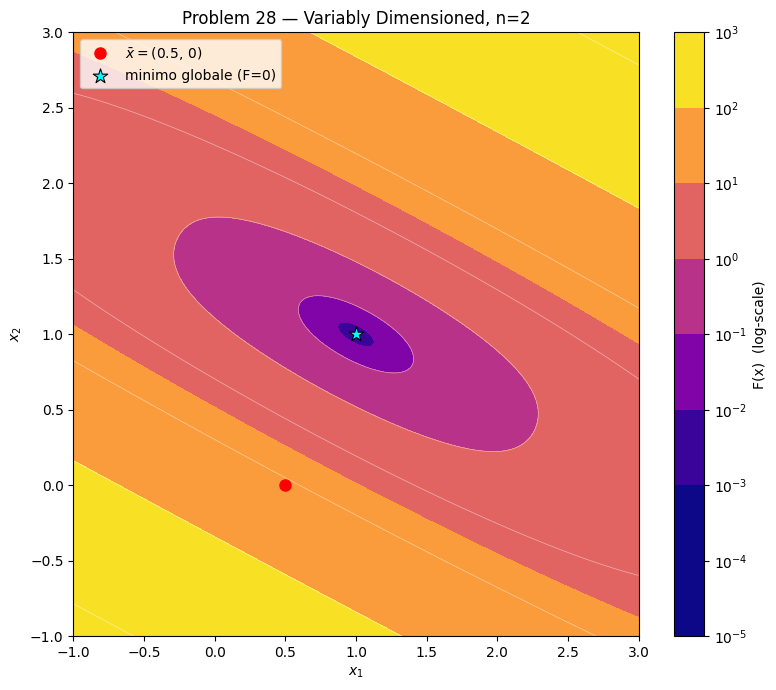

In [21]:
# Visualizzazione Problem 28, n=2
from matplotlib.colors import LogNorm

# Finestra centrata sul minimo globale x* = (1, 1)
x_lo, x_hi = -1.0, 3.0
x1_range = np.linspace(x_lo, x_hi, 400)
x2_range = np.linspace(x_lo, x_hi, 400)
X1, X2 = np.meshgrid(x1_range, x2_range)

Z = np.vectorize(lambda a, b: f28(np.array([a, b])))(X1, X2)

x_star = np.array([1.0, 1.0])      # minimo globale (F = 0)
x0_bar = x_bar_28(2)               # = (0.5, 0.0)

fig, ax = plt.subplots(figsize=(8, 7))
# log-scale: F cresce come ~ S^4 lungo la direzione j=(1,2);
# in scala lineare le curve di livello attorno a x* sarebbero schiacciate.
cf = ax.contourf(X1, X2, np.maximum(Z, 1e-6), levels=50,
                 norm=LogNorm(vmin=1e-3, vmax=Z.max()), cmap='plasma')
ax.contour(X1, X2, Z, levels=[0.1, 1, 5, 20, 100, 500, 2000],
           colors='white', linewidths=0.5, alpha=0.5)
ax.plot(x0_bar[0], x0_bar[1], 'ro', markersize=8,
        label=r'$\bar{x}=(0.5,\,0)$')
ax.scatter([x_star[0]], [x_star[1]], c='cyan', s=120, marker='*',
           edgecolor='black', linewidths=0.8,
           label='minimo globale (F=0)', zorder=5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Problem 28 — Variably Dimensioned, n=2')
plt.colorbar(cf, ax=ax, label='F(x)  (log-scale)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

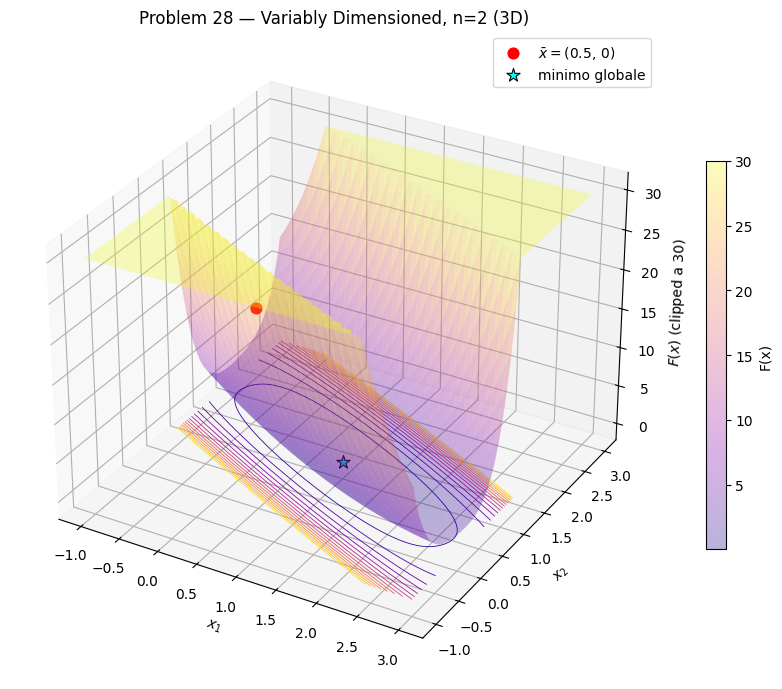

In [22]:
# Visualizzazione 3D Problem 28, n=2
# Nota: F cresce ~ S^4, quindi clippiamo Z per non schiacciare la struttura
# vicino al minimo globale.
Z_clip = np.minimum(Z, 30)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X1, X2, Z_clip, cmap='plasma',
                       linewidth=0, antialiased=True, alpha=0.3)
# isolinee proiettate sul piano di base (z=0)
ax.contour(X1, X2, Z_clip, zdir='z', offset=0, levels=15,
           cmap='plasma', linewidths=0.6)

# punto iniziale (clippato se necessario)
z_bar = min(float(f28(x0_bar)), 30)
ax.scatter([x0_bar[0]], [x0_bar[1]], [z_bar], color='red', s=60,
           label=r'$\bar{x}=(0.5,\,0)$')

# minimo globale
ax.scatter([x_star[0]], [x_star[1]], [0.0],
           c='cyan', s=100, marker='*', edgecolor='black',
           linewidths=0.8, label='minimo globale')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$F(x)$ (clipped a 30)')
ax.set_title('Problem 28 — Variably Dimensioned, n=2 (3D)')
fig.colorbar(surf, ax=ax, shrink=0.6, label='F(x)')
ax.view_init(elev=30, azim=-60)
ax.legend()
plt.tight_layout()
plt.show()

---
## Smoke test — Steepest Descent con stopping criteria swappabili

Eseguiamo lo stesso run (Problem 16, $n=2$, $\bar{x}=(1,1)$) con i 6 criteri di arresto, ognuno in isolamento. Tolleranze coerenti con le scale (vedi `stopping_criteria.md`):

- $\tau_g = 10^{-6}$ per i due criteri sul gradiente
- $\tau_f = 10^{-12}$ per i due criteri sulla differenza di $F$
- $\tau_x = 10^{-8}$ per i due criteri sulla differenza di $x$

In [23]:
from src.methods import steepest_descent
from src.stopping_criteria import all_criteria

# Minimo di riferimento (per Prob.16 n=2): ramo principale del reticolo
x_star_ref = np.array([np.arctan2(-2.0, 1.0), np.arctan2(1.0, 2.0)])  # (-1.107, 0.464)
F_star_ref = f16(x_star_ref)

x0 = x_bar_16(2)  # = (1, 1)

print(f"x0      = {x0},  F(x0) = {f16(x0):.6f}")
print(f"x*_ref  = ({x_star_ref[0]:+.6f}, {x_star_ref[1]:+.6f}),  F* = {F_star_ref:.6f}")
print()
print(f"{'criterion':<10} | {'iters':>5} | {'stop_reason':<10} | "
      f"{'F_final':>10} | {'|F-F*|':>10} | {'||x-x*||':>10} | {'||grad||':>10}")
print("-" * 90)

for crit in all_criteria(tol_g=1e-6, tol_f=1e-12, tol_x=1e-8):
    res = steepest_descent(f16, grad_f16, x0, stopping=crit, max_iter=2000)
    dx = float(np.linalg.norm(res['x_star'] - x_star_ref))
    dF = abs(res['f_star'] - F_star_ref)
    print(f"{crit.name:<10} | {res['n_iter']:>5} | {res['stop_reason']:<10} | "
          f"{res['f_star']:>10.6f} | {dF:>10.2e} | {dx:>10.2e} | "
          f"{res['grad_norm']:>10.2e}")

x0      = [1. 1.],  F(x0) = 2.220564
x*_ref  = (-1.107149, +0.463648),  F* = -1.472136

criterion  | iters | stop_reason |    F_final |     |F-F*| |   ||x-x*|| |   ||grad||
------------------------------------------------------------------------------------------
grad_abs   |     9 | grad_abs   |  -1.472136 |   1.13e-14 |   1.00e-07 |   2.24e-07
grad_rel   |     8 | grad_rel   |  -1.472136 |   8.05e-13 |   8.49e-07 |   1.90e-06
f_abs      |     9 | f_abs      |  -1.472136 |   1.13e-14 |   1.00e-07 |   2.24e-07
f_rel      |     9 | f_rel      |  -1.472136 |   1.13e-14 |   1.00e-07 |   2.24e-07
x_abs      |    12 | x_abs      |  -1.472136 |   2.22e-16 |   1.35e-09 |   3.01e-09
x_rel      |    12 | x_rel      |  -1.472136 |   2.22e-16 |   1.35e-09 |   3.01e-09
